# Monte Carlo Options Pricer — Results

Every figure and table below is produced from a fixed seed. Reference contract:
`S0 = K = 100`, `r = 5%`, `sigma = 20%`, `T = 1`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image

from mcpricer.binomial import binomial_american_put_price
from mcpricer.black_scholes import bs_call_price, bs_put_price
from mcpricer.pricing import lsm_american_price
from mcpricer.backtest import backtest_straddle
from mcpricer.data import load_market_data
from mcpricer.reporting import (
    greeks_table,
    plot_convergence,
    plot_hedging_backtest,
    plot_variance_reduction,
    plot_volatility_smiles,
)

BASE = dict(S0=100.0, K=100.0, r=0.05, sigma=0.2, T=1.0)
FIGURES = Path.cwd().parent / "figures"
FIGURES.mkdir(exist_ok=True)
bs_call_price(**BASE)

10.450583572185565

## 1. Convergence

The Monte Carlo price with its 95% interval against the closed-form price, and
the decay of the standard error against the `N^{-1/2}` reference line.

In [2]:
study = plot_convergence(FIGURES / "convergence.png")
pd.DataFrame(study).set_index("n_paths")

,price,standard_error
n_paths,,
100,10.194950,1.378802
300,9.515071,0.807351
1000,9.852283,0.455203
3000,10.081418,0.265486
10000,10.545612,0.147049
30000,10.583577,0.085487
100000,10.528683,0.046835
300000,10.449966,0.026859
1000000,10.453672,0.014727


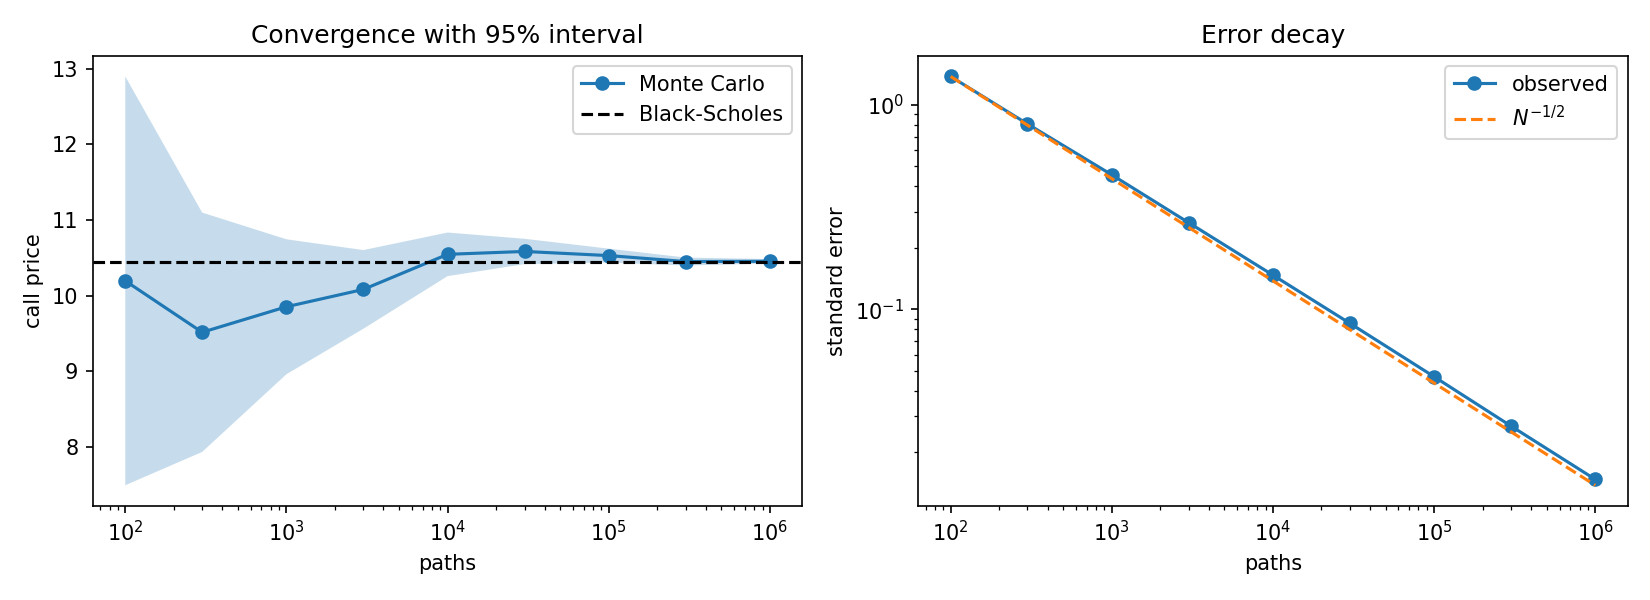

In [3]:
Image(FIGURES / "convergence.png")

## 2. Variance reduction

Both estimators are run at a matched path count, so the comparison is like for
like on payoff evaluations.

In [4]:
rows = plot_variance_reduction(FIGURES / "variance_reduction.png")
pd.DataFrame(rows)

,method,price,standard_error,seconds,variance_reduction_pct,efficiency_gain
0,naive,10.451341,0.020822,0.006174,0.000000,1.000000
1,antithetic,10.440919,0.014664,0.005132,50.404603,2.425869
2,control variate,10.446576,0.008343,0.006668,83.943416,5.766247


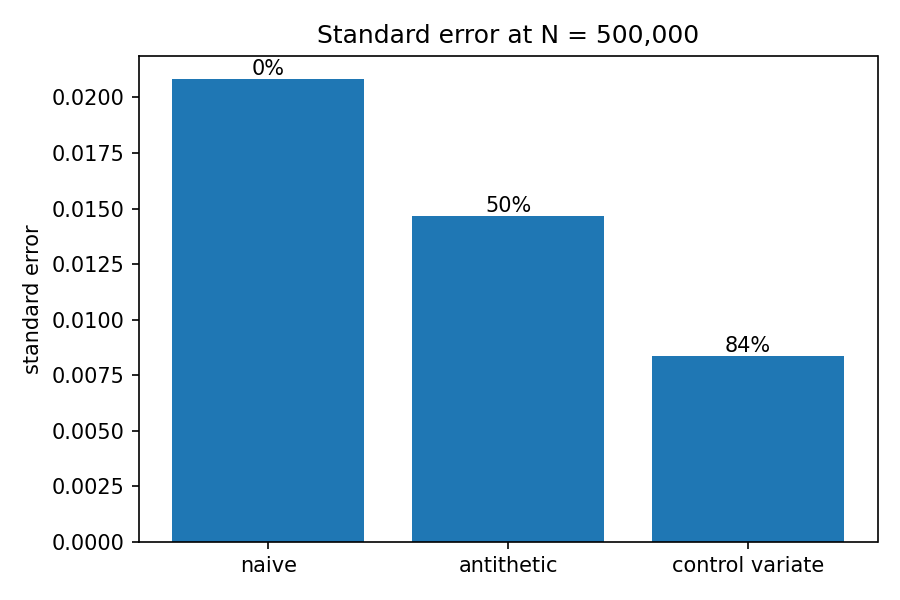

In [5]:
Image(FIGURES / "variance_reduction.png")

In [6]:
# Paths naive sampling would need to match the control variate's accuracy.
naive, control = rows[0], rows[2]
500_000 * (naive["standard_error"] / control["standard_error"]) ** 2

3113987.2935868

## 3. Greeks

Each estimator against its closed-form value, with the discrepancy expressed in
standard errors rather than absolute terms.

In [7]:
pd.DataFrame(greeks_table())

,greek,method,estimate,standard_error,closed_form,error_in_standard_errors
0,delta,finite difference,0.637150,0.000408,0.636831,0.782296
1,delta,pathwise,0.636370,0.000408,0.636831,1.130711
2,vega,finite difference,37.561239,0.053602,37.524035,0.694091
3,vega,pathwise,37.428133,0.053346,37.524035,1.797740
4,gamma,finite difference,0.018813,0.000076,0.018762,0.667027


## 4. American put

Longstaff-Schwartz against a binomial tree, plus the early exercise premium over
the European price.

In [8]:
lsm = lsm_american_price(**BASE, n_paths=500_000, n_steps=50, seed=5)
pd.DataFrame(
    [
        {"method": "Longstaff-Schwartz", "price": lsm.price, "standard_error": lsm.standard_error},
        {"method": "binomial tree", "price": binomial_american_put_price(**BASE, n_steps=4000), "standard_error": np.nan},
        {"method": "European (Black-Scholes)", "price": bs_put_price(**BASE), "standard_error": np.nan},
    ]
)

,method,price,standard_error
0,Longstaff-Schwartz,6.084609,0.010109
1,binomial tree,6.090181,NaN
2,European (Black-Scholes),5.573526,NaN


## 5. Volatility smiles

GBM is flat by construction. Merton's downward jumps lift the low strikes;
Heston's negative correlation between price and variance produces the equity
skew.

In [9]:
smiles = plot_volatility_smiles(FIGURES / "volatility_smiles.png")
pd.DataFrame(
    {k: v for k, v in smiles.items() if k != "strikes"},
    index=pd.Index(smiles["strikes"], name="strike"),
)

,GBM,Merton jumps,Heston
strike,,,
80.0,0.196294,0.248901,0.244716
85.0,0.197467,0.245382,0.230439
90.0,0.198113,0.242571,0.216314
95.0,0.198489,0.240378,0.202344
100.0,0.198661,0.238721,0.188678
105.0,0.198789,0.237458,0.175582
110.0,0.198876,0.236482,0.163448
115.0,0.198981,0.235757,0.152918
120.0,0.199092,0.235298,0.144815


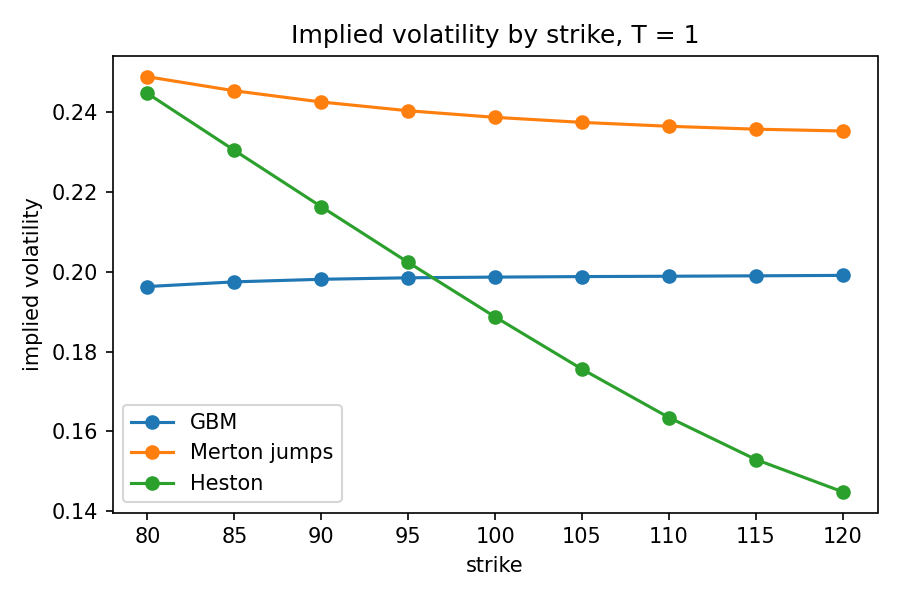

In [10]:
Image(FIGURES / "volatility_smiles.png")

## 6. Delta-hedged straddle backtest

The only part of this project with no oracle. Each cycle sells a one-month
at-the-money straddle on the S&P 500, hedges it with the engine's delta and
holds to expiry. Spot, implied volatility (VIX) and the discount rate
(1-month T-bill) are real daily observations.

In [11]:
market = load_market_data()
market.describe().loc[["count", "mean", "min", "max"]]

,spot,iv,rate
count,2495.000000,2495.000000,2495.000000
mean,4117.826265,0.186265,0.024143
min,2085.180000,0.091400,0.000000
max,7798.990000,0.826900,0.060200


### Scenarios

The VIX is a strip across strikes and sits above the at-the-money implied
volatility a straddle actually trades at, so `iv_offset` tests whether the
result survives selling at a lower volatility than the index prints.

In [12]:
scenarios = {
    "frictionless, daily": {},
    "IV -1.5pts, 1bp, daily": dict(iv_offset=-0.015, hedge_cost_bps=1.0),
    "IV -1.5pts, 1bp, weekly": dict(iv_offset=-0.015, hedge_cost_bps=1.0, rehedge_every=5),
    "IV -3pts, 1bp, daily": dict(iv_offset=-0.03, hedge_cost_bps=1.0),
    "unhedged, IV -1.5pts": dict(iv_offset=-0.015, hedge=False),
}
pd.DataFrame(
    {name: backtest_straddle(market, **kw).stats for name, kw in scenarios.items()}
).T[["annualised_return", "annualised_volatility", "sharpe", "max_drawdown", "hit_rate"]]

,annualised_return,annualised_volatility,sharpe,max_drawdown,hit_rate
"frictionless, daily",0.111677,0.052166,2.140793,-0.057291,0.838983
"IV -1.5pts, 1bp, daily",0.068422,0.052292,1.308458,-0.062839,0.822034
"IV -1.5pts, 1bp, weekly",0.075974,0.073272,1.036886,-0.142818,0.703390
"IV -3pts, 1bp, daily",0.028154,0.052442,0.536862,-0.105820,0.669492
"unhedged, IV -1.5pts",0.040686,0.114583,0.355081,-0.320223,0.618644


In [13]:
hedged, unhedged = plot_hedging_backtest(FIGURES / "hedging_backtest.png")
hedged.stats

{'n_cycles': 118.0,
 'total_return': 0.6728198157148527,
 'annualised_return': 0.0684223541404935,
 'annualised_volatility': 0.052292374845896904,
 'sharpe': 1.3084575780337164,
 'max_drawdown': -0.06283864438917208,
 'hit_rate': 0.8220338983050848,
 'worst_cycle': -0.04702063188276618,
 'best_cycle': 0.0372228469484403,
 'worst_day': -0.03625290973598671,
 'mean_entry_iv': 0.1729,
 'mean_realised_vol': 0.15112679577376373,
 'mean_variance_risk_premium': 0.021773204226236267}

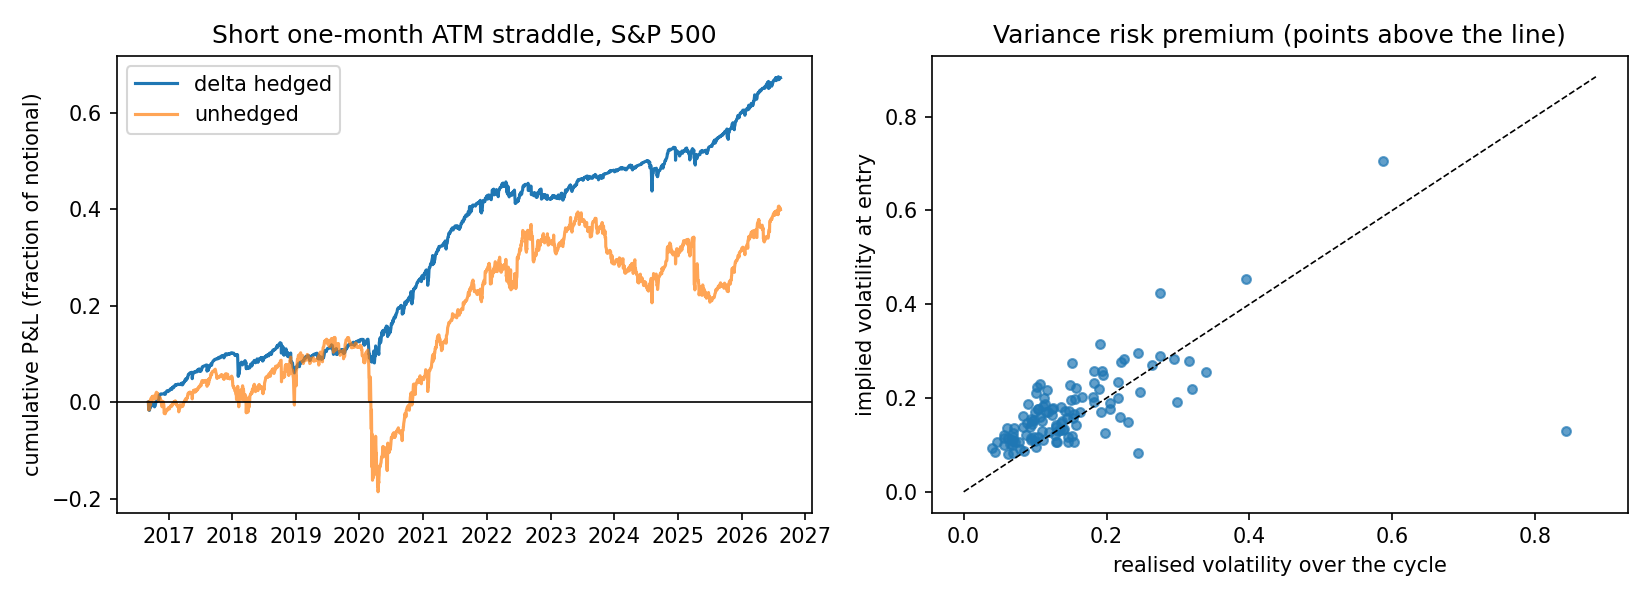

In [14]:
Image(FIGURES / "hedging_backtest.png")

### Where it loses

Short volatility pays steadily and loses violently. The five worst cycles carry
most of the drawdown, and the worst two are the February 2020 crash and the
February 2018 volatility spike.

In [15]:
hedged.cycles.nsmallest(5, "pnl")[
    ["entry_date", "entry_iv", "realised_vol", "variance_risk_premium", "pnl"]
]

,entry_date,entry_iv,realised_vol,variance_risk_premium,pnl
41,2020-02-19,0.1288,0.842768,-0.713968,-0.047021
16,2018-01-10,0.0832,0.243346,-0.160146,-0.044463
26,2018-11-09,0.1586,0.219345,-0.060745,-0.024025
67,2022-04-25,0.2552,0.339622,-0.084422,-0.022894
71,2022-08-24,0.2132,0.246608,-0.033408,-0.019405


**Reading the result.** Delta hedging, not the premium, is what produces the
Sharpe: the same position unhedged earns 0.36 with a 32% drawdown. The size of
the edge is dominated by the volatility level the straddle is sold at, which
without traded option quotes cannot be pinned down — hence the sensitivity
rather than a single headline number.

**Limitations.** No historical option chains: no bid-ask, no skew, no term
structure interpolation. Cycles are non-overlapping on a fixed calendar offset,
and 118 of them is a small sample for a strategy whose risk sits in the tail.